# EDA

In [199]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [200]:
import pandas as pd

In [201]:
df = pd.read_csv("customer_churn_data.csv")

In [202]:
df

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,NaN,2208.32,No,Yes
...,...,...,...,...,...,...,...,...,...,...
995,996,42,Male,41,37.14,Month-to-Month,Fiber Optic,1522.74,Yes,Yes
996,997,62,Male,9,80.93,Month-to-Month,NaN,728.37,No,Yes
997,998,51,Female,15,111.72,Month-to-Month,Fiber Optic,1675.80,Yes,Yes
998,999,39,Male,68,65.67,One-Year,NaN,4465.56,No,Yes


In [203]:
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,NaN,2208.32,No,Yes


In [204]:
df.shape

(1000, 10)

In [205]:
df.isna().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
MonthlyCharges       0
ContractType         0
InternetService    297
TotalCharges         0
TechSupport          0
Churn                0
dtype: int64

Fill empty values in InternetService column by empty string

In [206]:
df['InternetService'] = df['InternetService'].fillna("")

In [207]:
df.isna().sum().sum()

np.int64(0)

Check duplicates

In [208]:
df.duplicated().sum()

np.int64(0)

In [209]:
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,,2208.32,No,Yes


In [210]:
df.describe()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,44.674000,18.97300,74.391290,1404.364060
std,288.819436,9.797741,18.89257,25.712083,1571.755048
min,1.000000,12.000000,0.00000,30.000000,0.000000
25%,250.750000,38.000000,5.00000,52.357500,345.217500
50%,500.500000,45.000000,13.00000,74.060000,872.870000
75%,750.250000,51.000000,26.00000,96.102500,1900.175000
max,1000.000000,83.000000,122.00000,119.960000,12416.250000


In [211]:
numericColsData = df.select_dtypes(include= ['number'])

In [212]:
numericColsData

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
0,1,49,4,88.35,353.40
1,2,43,0,36.67,0.00
2,3,51,2,63.79,127.58
3,4,60,8,102.34,818.72
4,5,42,32,69.01,2208.32
...,...,...,...,...,...
995,996,42,41,37.14,1522.74
996,997,62,9,80.93,728.37
997,998,51,15,111.72,1675.80
998,999,39,68,65.67,4465.56


In [213]:
numericColsData.corr()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
CustomerID,1.000000,0.036730,-0.018585,-0.030504,-0.027490
Age,0.036730,1.000000,0.000472,0.006362,-0.001896
Tenure,-0.018585,0.000472,1.000000,-0.014552,0.894868
MonthlyCharges,-0.030504,0.006362,-0.014552,1.000000,0.304893
TotalCharges,-0.027490,-0.001896,0.894868,0.304893,1.000000


In [214]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [215]:
import matplotlib as plot

In [216]:
import matplotlib.pyplot as plt

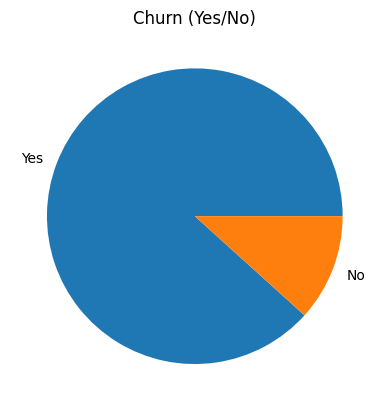

In [217]:
vals = df['Churn'].value_counts().plot(kind="pie")
plt.title("Churn (Yes/No)")
plt.ylabel("")
plt.show()

In [218]:
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     62.54641
Yes    75.96077
Name: MonthlyCharges, dtype: float64

In [219]:
df.groupby(["Churn", "Gender"])["MonthlyCharges"].mean()

Churn  Gender
No     Female    65.091912
       Male      59.013878
Yes    Female    74.975064
       Male      77.082518
Name: MonthlyCharges, dtype: float64

In [220]:
df.groupby(["Gender", "Churn"])["MonthlyCharges"].mean()

Gender  Churn
Female  No       65.091912
        Yes      74.975064
Male    No       59.013878
        Yes      77.082518
Name: MonthlyCharges, dtype: float64

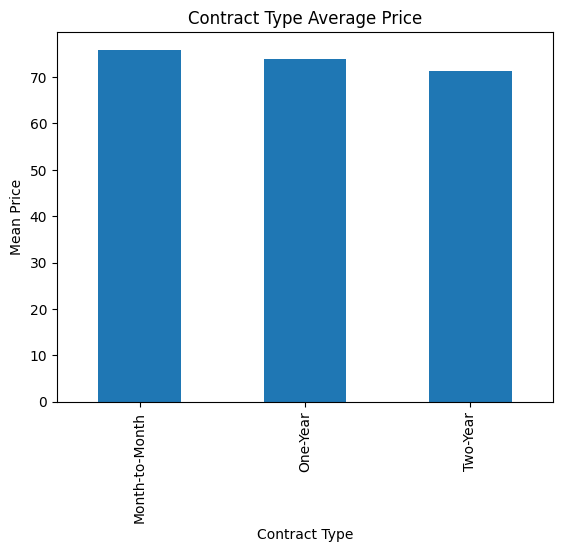

In [221]:
df.groupby("ContractType")["MonthlyCharges"].mean().plot(kind="bar")
plt.ylabel("Mean Price")
plt.xlabel("Contract Type")
plt.title("Contract Type Average Price")
plt.show()

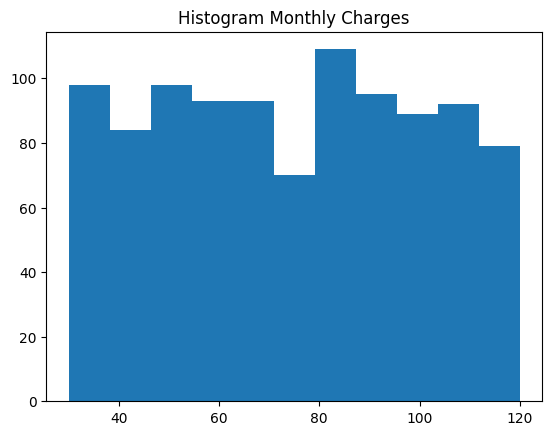

In [222]:
plt.hist(df["MonthlyCharges"], bins='auto')
plt.title("Histogram Monthly Charges")
plt.show()

In [223]:
df.head(2)

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.4,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.0,Yes,Yes


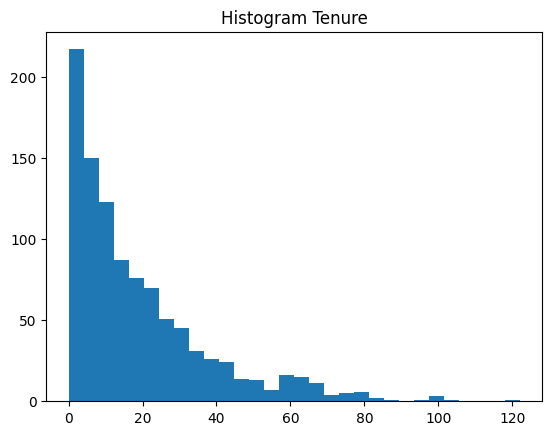

In [224]:
plt.hist(df["Tenure"], bins='auto')
plt.title("Histogram Tenure")
plt.show()

* Loaded data
* Checked for NA & duplicate values
* Took a look at numerical summaries & correlation
* Created charts
* Groupbys
* Created histograms


# Start Feature Engineernig
Select columns that we are going to use

In [225]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'MonthlyCharges',
       'ContractType', 'InternetService', 'TotalCharges', 'TechSupport',
       'Churn'],
      dtype='object')

In [226]:
df.head(2)

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.4,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.0,Yes,Yes


In [227]:
y = df[["Churn"]]
X = df[["Age", "Gender", "Tenure", "MonthlyCharges"]]

In [228]:
X

,Age,Gender,Tenure,MonthlyCharges
0,49,Male,4,88.35
1,43,Male,0,36.67
2,51,Female,2,63.79
3,60,Female,8,102.34
4,42,Male,32,69.01
...,...,...,...,...
995,42,Male,41,37.14
996,62,Male,9,80.93
997,51,Female,15,111.72
998,39,Male,68,65.67


In [229]:
y

,Churn
0,Yes
1,Yes
2,Yes
3,Yes
4,Yes
...,...
995,Yes
996,Yes
997,Yes
998,Yes


In [230]:
X["Gender"] = X["Gender"].apply(lambda x:1 if x == "Female" else 0)

In [231]:
X.head()

,Age,Gender,Tenure,MonthlyCharges
0,49,0,4,88.35
1,43,0,0,36.67
2,51,1,2,63.79
3,60,1,8,102.34
4,42,0,32,69.01


In [232]:
type(X["Gender"][0])

numpy.int64

In [233]:
y.head(1)

,Churn
0,Yes


In [234]:
y['Churn'] = y['Churn'].apply(lambda x: 1 if x == "Yes" else 0)

In [235]:
y["Churn"]

0      1
1      1
2      1
3      1
4      1
      ..
995    1
996    1
997    1
998    1
999    1
Name: Churn, Length: 1000, dtype: int64

In [236]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [237]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [238]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [239]:
X_train = scaler.fit_transform(X_train)

In [240]:
import joblib
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [241]:
X_test = scaler.transform(X_test)

In [242]:
from sklearn.metrics import accuracy_score

def modelPerformance(predictions):
    print("Accuracy Score on model is {}".format(accuracy_score(y_test, predictions)))

In [243]:
from sklearn.model_selection import GridSearchCV

# Logistic Regression

In [244]:
from sklearn.linear_model import LogisticRegression

In [245]:
log_model = LogisticRegression(class_weight="balanced")

In [246]:
import warnings
warnings.filterwarnings("ignore")

In [247]:
log_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [248]:
y_pred = log_model.predict(X_test)

In [249]:
modelPerformance(y_pred)

Accuracy Score on model is 0.665


# KNeighborsClassifier

In [250]:
from sklearn.neighbors import KNeighborsClassifier

In [251]:
param_grid = {
    "n_neighbors": [3,5,7,9],
    "weights": ["uniform", "distance"]
}

In [252]:
gridkn = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)

In [253]:
gridkn.fit(X_train, y_train)

,estimator,KNeighborsClassifier()
,param_grid,"{'n_neighbors': [3, 5, ...], 'weights': ['uniform', 'distance']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,9


In [254]:
gridkn.best_params_

{'n_neighbors': 9, 'weights': 'uniform'}

In [255]:
y_pred = gridkn.predict(X_test)

In [256]:
modelPerformance(y_pred)

Accuracy Score on model is 0.885


# Support Vector Classifier

In [257]:
from sklearn.svm import SVC

In [258]:
svm = SVC(class_weight="balanced")

In [259]:
param_grid = {
    "C": [0.01, 0.1, 0.5, 1],
    "kernel": ["linear", "rbf", "poly"]
}

In [260]:
gridsvc = GridSearchCV(svm, param_grid, cv = 5)

In [261]:
gridsvc.fit(X_train, y_train)

,estimator,SVC(class_weight='balanced')
,param_grid,"{'C': [0.01, 0.1, ...], 'kernel': ['linear', 'rbf', ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,0.01


In [262]:
gridsvc.best_params_

{'C': 0.01, 'kernel': 'poly'}

In [263]:
y_pred = gridsvc.predict(X_test)

In [264]:
modelPerformance(y_pred)

Accuracy Score on model is 0.75


# Models Trained:
* logistic
* kNeighbours
* SVM
* Decision Tree
* Random Forest

# Decision Tree

In [265]:
from sklearn.tree import DecisionTreeClassifier

In [266]:
param_grid = {
    "criterion": ["gini", "entropy"],
    "splitter": ["best", "random"],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [267]:
grid_tree = GridSearchCV(DecisionTreeClassifier(class_weight="balanced"), param_grid, cv=5)

In [268]:
grid_tree.fit(X_train, y_train)

,estimator,DecisionTreeC...ht='balanced')
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [269]:
grid_tree.best_params_

{'criterion': 'entropy',
 'max_depth': 30,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'splitter': 'best'}

In [270]:
y_pred = grid_tree.predict(X_test)

In [271]:
y_pred

array([1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0,
       1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1])

In [272]:
modelPerformance(y_pred)

Accuracy Score on model is 0.815


# Random Forest

In [273]:
from sklearn.ensemble import RandomForestClassifier

In [274]:
rfc_model = RandomForestClassifier(class_weight="balanced")

In [275]:
param_grid = {
    "n_estimators" : [32, 64, 128, 256],
    "max_features": [2,3,4],
    "bootstrap": [True, False]
}

In [276]:
grid_rfc = GridSearchCV(rfc_model, param_grid, cv=5)

In [277]:
grid_rfc.fit(X_train, y_train)

,estimator,RandomForestC...ht='balanced')
,param_grid,"{'bootstrap': [True, False], 'max_features': [2, 3, ...], 'n_estimators': [32, 64, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,128


In [278]:
grid_rfc.best_params_

{'bootstrap': True, 'max_features': 2, 'n_estimators': 128}

In [279]:
y_pred = grid_rfc.predict(X_test)

In [280]:
modelPerformance(y_pred)

Accuracy Score on model is 0.875


In [281]:
from sklearn.metrics import accuracy_score
import joblib

candidates = {
    "log": log_model,       
    "knn": gridkn.best_estimator_,
    # "svm": gridsvc.best_estimator_,
    "dt": grid_tree.best_estimator_,
    "rf": grid_rfc.best_estimator_
}

best_name = None
best_acc = -1
best_model = None

for name, model in candidates.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(name, "accuracy:", acc)
    if acc > best_acc:
        best_acc = acc
        best_name = name
        best_model = model

print("Best:", best_name, best_acc)
joblib.dump(best_model, "model.pkl")


log accuracy: 0.665
knn accuracy: 0.885
dt accuracy: 0.815
rf accuracy: 0.875
Best: knn 0.885


['model.pkl']

In [282]:
X

,Age,Gender,Tenure,MonthlyCharges
0,49,0,4,88.35
1,43,0,0,36.67
2,51,1,2,63.79
3,60,1,8,102.34
4,42,0,32,69.01
...,...,...,...,...
995,42,0,41,37.14
996,62,0,9,80.93
997,51,1,15,111.72
998,39,0,68,65.67
